Initializing portfolio with 5 assets: AAPL, MSFT, GOOGL, JPM, JNJ

Fetching 3y of historical data from Yahoo Finance...
✓ Successfully fetched data for 751 trading days
  Date range: 2022-12-12 to 2025-12-09

Individual Asset Statistics (Annualized):
Ticker  Expected Return (%)  Volatility (%)
  AAPL            25.773424       26.081181
  MSFT            46.007591       30.447139
 GOOGL             8.454885       17.039928
   JPM            32.221964       22.992320
   JNJ            25.936538       23.389448

PORTFOLIO STRATEGY COMPARISON

      Strategy  Return (%)  Volatility (%)  Sharpe Ratio
  Equal Weight   27.678880       15.711693      1.507086
    Max Sharpe   34.472554       18.332877      1.662181
Min Volatility   18.450168       12.650478      1.142263



MINIMUM VOLATILITY PORTFOLIO

Portfolio Metrics:
  Expected Annual Return: 18.45%
  Annual Volatility (Risk): 12.65%
  Sharpe Ratio: 1.142

Optimal Allocation:
Ticker  Weight (%)  Expected Return
 GOOGL   53.656395        

Enter total investment amount ($):  1000000



For $1,000,000.00 investment:

  AAPL: $44,507.48 (4.45%)
  MSFT: $47,105.94 (4.71%)
  GOOGL: $536,563.95 (53.66%)
  JPM: $152,010.14 (15.20%)
  JNJ: $219,812.49 (21.98%)



Generating efficient frontier...


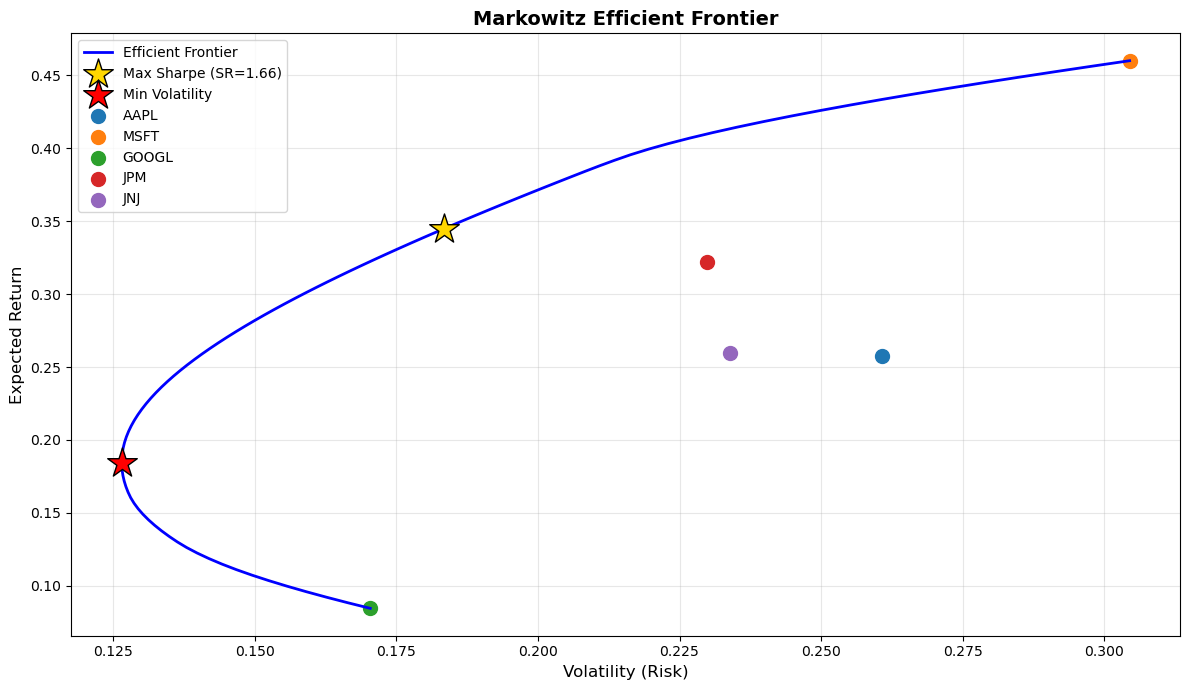

In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from datetime import datetime, timedelta

class MarkowitzPortfolioOptimizer:
    """
    Markowitz Mean-Variance Portfolio Optimization Model.
    Automatically fetches data from Yahoo Finance and optimizes portfolio allocation.
    """
    
    def __init__(self, tickers, period='3y', risk_free_rate=0.04):
        """
        Initialize the portfolio optimizer.
        
        Parameters:
        - tickers: List of stock ticker symbols (e.g., ['AAPL', 'MSFT', 'GOOGL'])
        - period: Historical data period ('1y', '2y', '3y', '5y', '10y', 'max')
        - risk_free_rate: Annual risk-free rate (default 4%)
        """
        self.tickers = tickers
        self.period = period
        self.risk_free_rate = risk_free_rate
        self.n_assets = len(tickers)
        
        # Data storage
        self.prices = None
        self.returns = None
        self.mean_returns = None
        self.cov_matrix = None
        self.optimal_weights = None
        
        print(f"Initializing portfolio with {self.n_assets} assets: {', '.join(tickers)}")
        
    def fetch_data(self):
        """Fetch historical price data from Yahoo Finance."""
        print(f"\nFetching {self.period} of historical data from Yahoo Finance...")
        
        try:
            # Download data
            data = yf.download(self.tickers, period=self.period, progress=False, auto_adjust=True)
            
            # Handle single vs multiple tickers
            if len(self.tickers) == 1:
                # Single ticker: data is a simple DataFrame
                self.prices = data[['Close']].copy()
                self.prices.columns = self.tickers
            else:
                # Multiple tickers: extract Close prices
                if 'Close' in data.columns:
                    self.prices = data['Close'].copy()
                else:
                    # Fallback if structure is different
                    self.prices = data.copy()
            
            # Remove any NaN values
            self.prices = self.prices.dropna()
            
            # Calculate daily returns
            self.returns = self.prices.pct_change().dropna()
            
            # Calculate annualized mean returns (252 trading days)
            self.mean_returns = self.returns.mean() * 252
            
            # Calculate annualized covariance matrix
            self.cov_matrix = self.returns.cov() * 252
            
            print(f"✓ Successfully fetched data for {len(self.prices)} trading days")
            print(f"  Date range: {self.prices.index[0].date()} to {self.prices.index[-1].date()}")
            
            return True
            
        except Exception as e:
            print(f"✗ Error fetching data: {e}")
            import traceback
            traceback.print_exc()
            return False
    
    def portfolio_performance(self, weights):
        """
        Calculate portfolio performance metrics.
        
        Returns: (expected_return, volatility, sharpe_ratio)
        """
        weights = np.array(weights)
        
        # Portfolio return
        portfolio_return = np.sum(self.mean_returns * weights)
        
        # Portfolio volatility (risk)
        portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(self.cov_matrix, weights)))
        
        # Sharpe ratio
        sharpe_ratio = (portfolio_return - self.risk_free_rate) / portfolio_volatility
        
        return portfolio_return, portfolio_volatility, sharpe_ratio
    
    def negative_sharpe(self, weights):
        """Objective function to minimize (negative Sharpe ratio)."""
        return -self.portfolio_performance(weights)[2]
    
    def optimize_portfolio(self, target='max_sharpe', target_return=None):
        """
        Optimize portfolio allocation.
        
        Parameters:
        - target: 'max_sharpe' (default), 'min_volatility', or 'target_return'
        - target_return: Required if target='target_return'
        
        Returns: Optimal weights
        """
        # Constraints: weights sum to 1
        constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - 1}]
        
        # Bounds: weights between 0 and 1 (no short selling)
        bounds = tuple((0, 1) for _ in range(self.n_assets))
        
        # Initial guess: equal weights
        initial_weights = np.array([1/self.n_assets] * self.n_assets)
        
        if target == 'max_sharpe':
            # Maximize Sharpe ratio
            result = minimize(
                self.negative_sharpe,
                initial_weights,
                method='SLSQP',
                bounds=bounds,
                constraints=constraints
            )
            
        elif target == 'min_volatility':
            # Minimize volatility
            result = minimize(
                lambda w: self.portfolio_performance(w)[1],
                initial_weights,
                method='SLSQP',
                bounds=bounds,
                constraints=constraints
            )
            
        elif target == 'target_return':
            if target_return is None:
                raise ValueError("target_return must be specified")
            
            # Add return constraint
            constraints.append({
                'type': 'eq',
                'fun': lambda w: self.portfolio_performance(w)[0] - target_return
            })
            
            result = minimize(
                lambda w: self.portfolio_performance(w)[1],
                initial_weights,
                method='SLSQP',
                bounds=bounds,
                constraints=constraints
            )
        
        if result.success:
            self.optimal_weights = result.x
            return result.x
        else:
            print(f"Optimization failed: {result.message}")
            return None
    
    def generate_efficient_frontier(self, n_portfolios=100):
        """
        Generate efficient frontier by optimizing for different target returns.
        
        Returns: DataFrame with frontier portfolios
        """
        # Get range of possible returns
        min_return = self.mean_returns.min()
        max_return = self.mean_returns.max()
        target_returns = np.linspace(min_return, max_return, n_portfolios)
        
        frontier_returns = []
        frontier_volatilities = []
        frontier_sharpes = []
        
        print("\nGenerating efficient frontier...")
        
        for target_ret in target_returns:
            try:
                weights = self.optimize_portfolio(target='target_return', target_return=target_ret)
                if weights is not None:
                    ret, vol, sharpe = self.portfolio_performance(weights)
                    frontier_returns.append(ret)
                    frontier_volatilities.append(vol)
                    frontier_sharpes.append(sharpe)
            except:
                continue
        
        return pd.DataFrame({
            'Return': frontier_returns,
            'Volatility': frontier_volatilities,
            'Sharpe': frontier_sharpes
        })
    
    def plot_efficient_frontier(self, show_assets=True):
        """Visualize the efficient frontier."""
        # Generate frontier
        frontier = self.generate_efficient_frontier()
        
        # Get optimal portfolios
        weights_max_sharpe = self.optimize_portfolio(target='max_sharpe')
        weights_min_vol = self.optimize_portfolio(target='min_volatility')
        
        ret_max_sharpe, vol_max_sharpe, sharpe_max_sharpe = self.portfolio_performance(weights_max_sharpe)
        ret_min_vol, vol_min_vol, sharpe_min_vol = self.portfolio_performance(weights_min_vol)
        
        # Plot
        plt.figure(figsize=(12, 7))
        
        # Efficient frontier
        plt.plot(frontier['Volatility'], frontier['Return'], 'b-', linewidth=2, label='Efficient Frontier')
        
        # Optimal portfolios
        plt.scatter(vol_max_sharpe, ret_max_sharpe, marker='*', s=500, c='gold', 
                   edgecolors='black', label=f'Max Sharpe (SR={sharpe_max_sharpe:.2f})', zorder=5)
        plt.scatter(vol_min_vol, ret_min_vol, marker='*', s=500, c='red',
                   edgecolors='black', label=f'Min Volatility', zorder=5)
        
        # Individual assets
        if show_assets:
            for i, ticker in enumerate(self.tickers):
                plt.scatter(np.sqrt(self.cov_matrix.iloc[i, i]), 
                          self.mean_returns.iloc[i],
                          marker='o', s=100, label=ticker)
        
        plt.xlabel('Volatility (Risk)', fontsize=12)
        plt.ylabel('Expected Return', fontsize=12)
        plt.title('Markowitz Efficient Frontier', fontsize=14, fontweight='bold')
        plt.legend(loc='best', fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    def display_optimal_portfolio(self, portfolio_type='max_sharpe'):
        """Display optimal portfolio allocation and metrics."""
        if portfolio_type == 'max_sharpe':
            weights = self.optimize_portfolio(target='max_sharpe')
            title = "MAXIMUM SHARPE RATIO PORTFOLIO"
        else:
            weights = self.optimize_portfolio(target='min_volatility')
            title = "MINIMUM VOLATILITY PORTFOLIO"
        
        if weights is None:
            print("Optimization failed")
            return
        
        ret, vol, sharpe = self.portfolio_performance(weights)
        
        print(f"\n{'='*70}")
        print(f"{title}")
        print(f"{'='*70}\n")
        
        print(f"Portfolio Metrics:")
        print(f"  Expected Annual Return: {ret*100:.2f}%")
        print(f"  Annual Volatility (Risk): {vol*100:.2f}%")
        print(f"  Sharpe Ratio: {sharpe:.3f}")
        print(f"\nOptimal Allocation:")
        
        allocation_df = pd.DataFrame({
            'Ticker': self.tickers,
            'Weight (%)': weights * 100,
            'Expected Return': self.mean_returns * 100
        }).sort_values('Weight (%)', ascending=False)
        
        print(allocation_df.to_string(index=False))
        
        # Investment calculator
        print(f"\n{'='*70}")
        print("Investment Amount Calculator")
        print(f"{'='*70}\n")
        
        investment = float(input("Enter total investment amount ($): "))
        
        print(f"\nFor ${investment:,.2f} investment:\n")
        for ticker, weight in zip(self.tickers, weights):
            amount = investment * weight
            print(f"  {ticker}: ${amount:,.2f} ({weight*100:.2f}%)")
        
        print(f"\n{'='*70}\n")
        
        return weights, ret, vol, sharpe
    
    def compare_portfolios(self):
        """Compare different portfolio strategies."""
        # Equal weight portfolio
        equal_weights = np.array([1/self.n_assets] * self.n_assets)
        eq_ret, eq_vol, eq_sharpe = self.portfolio_performance(equal_weights)
        
        # Max Sharpe portfolio
        max_sharpe_weights = self.optimize_portfolio(target='max_sharpe')
        ms_ret, ms_vol, ms_sharpe = self.portfolio_performance(max_sharpe_weights)
        
        # Min volatility portfolio
        min_vol_weights = self.optimize_portfolio(target='min_volatility')
        mv_ret, mv_vol, mv_sharpe = self.portfolio_performance(min_vol_weights)
        
        comparison = pd.DataFrame({
            'Strategy': ['Equal Weight', 'Max Sharpe', 'Min Volatility'],
            'Return (%)': [eq_ret*100, ms_ret*100, mv_ret*100],
            'Volatility (%)': [eq_vol*100, ms_vol*100, mv_vol*100],
            'Sharpe Ratio': [eq_sharpe, ms_sharpe, mv_sharpe]
        })
        
        print(f"\n{'='*70}")
        print("PORTFOLIO STRATEGY COMPARISON")
        print(f"{'='*70}\n")
        print(comparison.to_string(index=False))
        print(f"\n{'='*70}\n")
        
        return comparison


# Example Usage
if __name__ == "__main__":
    # Define your portfolio tickers
    tickers = ['AAPL', 'MSFT', 'GOOGL', 'JPM', 'JNJ']
    
    # Initialize optimizer
    optimizer = MarkowitzPortfolioOptimizer(
        tickers=tickers,
        period='3y',  # 3 years of historical data
        risk_free_rate=0.04  # 4% risk-free rate
    )
    
    # Fetch data from Yahoo Finance
    if optimizer.fetch_data():
        
        # Display individual asset statistics
        print("\nIndividual Asset Statistics (Annualized):")
        stats = pd.DataFrame({
            'Ticker': tickers,
            'Expected Return (%)': optimizer.mean_returns * 100,
            'Volatility (%)': np.sqrt(np.diag(optimizer.cov_matrix)) * 100
        })
        print(stats.to_string(index=False))
        
        # Compare different strategies
        optimizer.compare_portfolios()
        
        # Display optimal portfolio with investment calculator
        optimizer.display_optimal_portfolio(portfolio_type='min_volatility')
        
        # Plot efficient frontier
        optimizer.plot_efficient_frontier()